# Forward Equilibrium with TokaMaker

This notebook runs the **TokaMaker** free-boundary Grad-Shafranov solver from the
[Open FUSION Toolkit](https://github.com/openfusiontoolkit/OpenFUSIONToolkit)
(arXiv:2311.07719) through `vaft.code.tokamaker` — the same forward workflow as the
TES notebook, but with an open-source, in-process solver:

    ods ── tokamaker_geometry_from_ods ─▶ geometry dict
        ── build_tokamaker_mesh ────────▶ vest_gs_mesh_<hash>.h5   (cached)
        ── prepare_tokamaker_inputs ────▶ TokaMakerInputs
        ── run_tokamaker (in-process) ──▶ g<shot>.<time> + tokamaker_result.json
        ── collect_tokamaker_outputs ───▶ ods.equilibrium  (via vaft.data.eqdsk)

*Forward* means the VEST PF coil currents are prescribed from `pf_active` at the case
time and the solver finds the equilibrium matching the global targets (Ip and, when
given, `pax`/`R0`/`V0`). The exported g-file uses **COCOS 2** — the convention of the
VEST EFIT g-files — so it round-trips through `vaft.data.eqdsk` unchanged.

Input preparation and this notebook's data cells work without OpenFUSIONToolkit;
meshing/solve cells are skipped when the package is not importable (see
`initialize_external_fusion_codes.ipynb` for install and environment options).

In [ ]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from omas import ODS

import vaft
from vaft.code import tokamaker

WORKDIR = Path("_tokamaker_run").resolve()
WORKDIR.mkdir(exist_ok=True)

try:
    tokamaker._oft.import_oft()
    OFT_AVAILABLE = True
except ImportError as exc:
    OFT_AVAILABLE = False
    print(exc)
print("OpenFUSIONToolkit available:", OFT_AVAILABLE)
print("work :", WORKDIR)

OpenFUSIONToolkit available: True
work : <repo>/notebooks/_tokamaker_run


## 1. Load an arbitrary shot with `vaft.database.load`

Any ODS that carries `wall`, `pf_active`, `magnetics`, `tf` (and, for target
resolution and comparison, `equilibrium`) can drive the solve. Offline, the bundled
sample shot ships with the package.

Database `wall` entries vary by processing era (some carry only a partial
center-stack outline), so the canonical VEST limiter from the packaged static
geometry is applied after loading — the free-boundary solve needs the full vessel
contour.

In [ ]:
SHOT, TIME = 39915, 0.325
try:
    ods = vaft.database.load(SHOT)                 # arbitrary shot from the VEST database
    print(f"loaded shot {SHOT} via vaft.database.load")
except Exception as e:
    from vaft.omas.sample import sample_ods
    ods = sample_ods(SHOT)                         # packaged sample: vaft/data/samples/<shot>/
    print(f"vaft.database.load unavailable ({type(e).__name__}); using the packaged sample of {SHOT}")

# Canonical VEST limiter — database wall entries vary by era and may be partial.
from vaft.machine_mapping.wall import wall as canonical_wall
canonical_wall(ods)

mg = ods["magnetics"]
ip_kA = np.interp(TIME, mg["ip.0.time"], mg["ip.0.data"]) / 1e3
f0 = np.interp(TIME, ods["tf.time"], ods["tf.b_field_tor_vacuum_r.data"])
print(f"shot {SHOT}  t={TIME*1e3:.0f} ms")
print(f"  Ip(t)        = {ip_kA:.1f} kA   (from magnetics.ip)")
print(f"  F0 = R0*B0   = {f0:.4f} T·m (from tf.b_field_tor_vacuum_r)")
print(f"  pf_active    = {len(ods['pf_active.coil'])} coils")
print(f"  equilibrium  = {len(ods['equilibrium.time'])} time slices")
print(f"  wall limiter = {len(ods['wall.description_2d.0.limiter.unit.0.outline.r'])} points")

<tmp> RuntimeWarning: Could not infer IMAS DD version for HSDS source 'main' shot 39915; using 3.41.0


vaft.database.load unavailable (HSDSCommandError); using the packaged sample of 39915


shot 39915  t=325 ms
  Ip(t)        = 51.2 kA   (from magnetics.ip)
  F0 = R0*B0   = 0.0601 T·m (from tf.b_field_tor_vacuum_r)
  pf_active    = 10 coils
  equilibrium  = 9 time slices
  wall limiter = 17 points


## 2. Machine geometry: limiter + coil rectangles

`tokamaker_geometry_from_ods` reads the wall limiter and the `pf_active` rectangle
elements directly. Each up/down-mirrored coil becomes two mesh rectangles
(`PFn_U`/`PFn_L`) sharing one TokaMaker *coil set* `PFn` — the unit of current
control — with the signed sum of `turns_with_sign` as its turns.

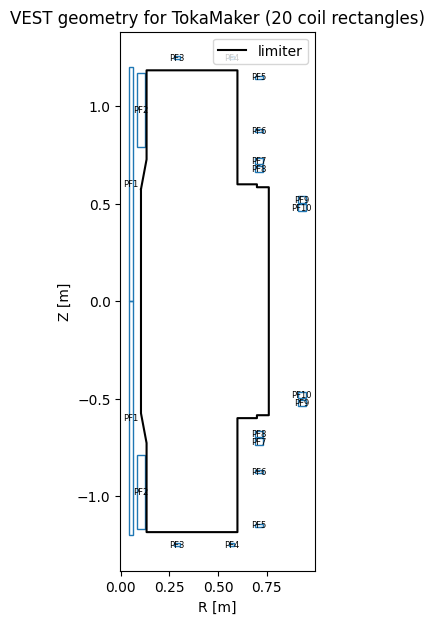

In [ ]:
cfg = tokamaker.TokaMakerConfig(shot=SHOT, time=TIME, workdir=WORKDIR)
geometry = tokamaker.tokamaker_geometry_from_ods(ods, cfg)

lim = np.asarray(geometry["limiter"])
fig, ax = plt.subplots(figsize=(5, 7))
ax.plot(np.r_[lim[:, 0], lim[0, 0]], np.r_[lim[:, 1], lim[0, 1]], "k-", lw=1.5, label="limiter")
for name, coil in geometry["coils"].items():
    ax.add_patch(plt.Rectangle((coil["rc"] - coil["w"] / 2, coil["zc"] - coil["h"] / 2),
                               coil["w"], coil["h"], fill=False, edgecolor="tab:blue"))
    ax.annotate(coil["coil_set"], (coil["rc"], coil["zc"]), fontsize=6, ha="center", va="center")
ax.set_xlabel("R [m]"); ax.set_ylabel("Z [m]"); ax.set_aspect("equal")
ax.set_title(f"VEST geometry for TokaMaker ({len(geometry['coils'])} coil rectangles)")
ax.legend(loc="upper right")
plt.show()

## 3. Prepare inputs and build the mesh (cached)

`prepare_tokamaker_inputs` resolves the targets, `F0`, and per-coil currents from
the ODS — no OpenFUSIONToolkit needed. Meshing is the slow step and depends only on
geometry and the `dx_*` resolutions, so the mesh is cached as
`vest_gs_mesh_<hash>.h5`: re-running this notebook (or scanning currents/targets)
reuses it.

In [ ]:
inputs = tokamaker.prepare_tokamaker_inputs(ods, cfg)
print("targets       :", {k: round(v, 1) for k, v in inputs.targets.items()})
print("F0 [T·m]      :", round(inputs.f0, 4))
print("coil currents :", {k: round(v, 1) for k, v in sorted(inputs.coil_currents.items())})
print("mesh file     :", inputs.mesh_file.name, "(cached)" if inputs.mesh_exists else "(to build)")

if OFT_AVAILABLE and not inputs.mesh_exists:
    import time as _time
    t0 = _time.time()
    tokamaker.build_tokamaker_mesh(inputs.geometry, inputs.mesh_file, cfg)
    print(f"mesh built in {_time.time() - t0:.1f} s")
elif not OFT_AVAILABLE:
    print("OpenFUSIONToolkit not available — skipping mesh build")

targets       : {'Ip': 51048.2}
F0 [T·m]      : 0.0601
coil currents : {'PF1': -5554.6, 'PF10': -522.1, 'PF2': 0.0, 'PF3': 0.0, 'PF4': 0.0, 'PF5': 201.4, 'PF6': -1431.8, 'PF7': 0.0, 'PF8': 0.0, 'PF9': -522.1}
mesh file     : vest_gs_mesh_8d7132c0b8.h5 (cached)


## 4. Run the forward solve

`run_tokamaker` drives the canonical TokaMaker sequence in-process (mesh → regions
→ `setup` → coil currents → targets → power-law profiles → `init_psi` → `solve`)
and exports `g<shot>.<time_ms>`. A failed solve is reported through
`result.ok`/`result.error` instead of raising, like the subprocess adapters.

In [ ]:
if OFT_AVAILABLE:
    result = tokamaker.run_tokamaker(inputs, cfg)
    print("ok:", result.ok, "  returncode:", result.returncode)
    if result.ok:
        s = result.scalars
        keys = ("Ip", "R_geo", "a_geo", "kappa", "delta", "q_0", "q_95", "beta_pol", "l_i")
        print("g-file:", result.gfile.name)
        for k in keys:
            print(f"  {k:9s} = {s[k]:.4g}")
        print("  solved coil currents [A]:",
              {k: round(v, 1) for k, v in sorted(s["coil_currents_A"].items())})
    else:
        print("error:", result.error)
else:
    print("OpenFUSIONToolkit not available — skipping the solve")

#----------------------------------------------
Open FUSION Toolkit Initialized
Development branch:    main
Revision id:           6d56801
Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2
Fortran input file    = <tmp>
XML input file        = none
Integer Precisions    =    4   8
Float Precisions      =    4   8  16
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  3.444E+00
    # of points  =   12541
    # of edges   =   37456
    # of cells   =   24916
    # of boundary points =     164
    # of boundary edges  =     164
    # of boundary cells  =     164
  Resolution statistics:
    hmin =  6.233E-03
    hrms =  1.904E-02
    hmax =  7.829E-02
  Surface grounded at vertex    1272


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Comput

Saving gEQDSK: <repo>/notebooks/_tokamaker_run/g039915.00325
 Using COCOS=2...
ok: True   returncode: 0
g-file: g039915.00325
  Ip        = 5.104e+04
  R_geo     = 0.3431
  a_geo     = 0.1764
  kappa     = 1.18
  delta     = 0.09623
  q_0       = 0.72
  q_95      = 2.374
  beta_pol  = 5.76
  l_i       = 1.198
  solved coil currents [A]: {'PF1': -5554.6, 'PF10': -522.1, 'PF2': 0.0, 'PF3': 0.0, 'PF4': 0.0, 'PF5': 201.4, 'PF6': -1431.8, 'PF7': 0.0, 'PF8': 0.0, 'PF9': -522.1}


## 5. Equilibrium back in an ODS — 2D overview

`collect_tokamaker_outputs` already converted the g-file into `result.ods`
(`equilibrium.time_slice.0`), so every `vaft` equilibrium plot works unchanged.

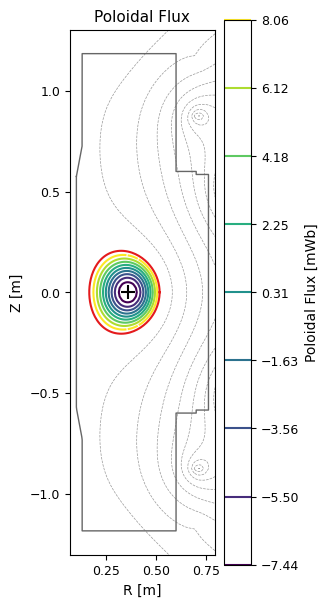

In [ ]:
if OFT_AVAILABLE and result.ok:
    vaft.omas.plot_equilibrium_field_psi(result.ods, time_slice=0)
    plt.show()
else:
    print("no converged equilibrium to plot")

## 6. 1D flux-function profiles

The g-file flux functions (p, q, p′, FF′) against normalized poloidal flux. Without
a `pax` target the pressure amplitude follows TokaMaker's internal normalization —
supply `TokaMakerConfig.pax` (or `ip_ratio`) to pin it.

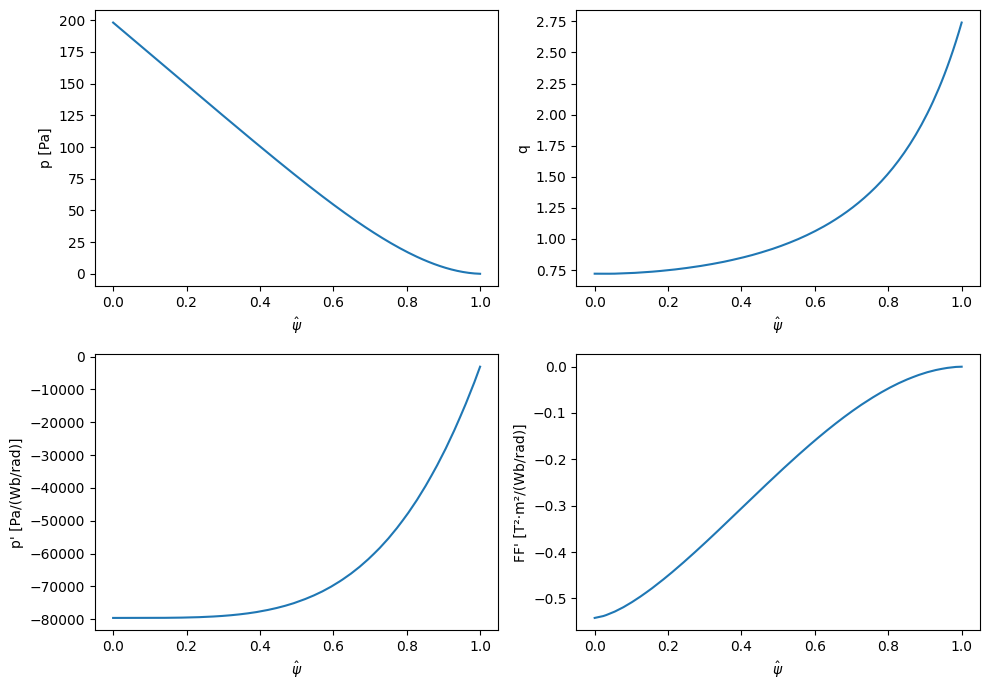

In [ ]:
if OFT_AVAILABLE and result.ok:
    g = result.geqdsk[0]
    psin = np.linspace(0.0, 1.0, len(g["PRES"]))
    fig, ax = plt.subplots(2, 2, figsize=(10, 7))
    ax[0, 0].plot(psin, g["PRES"]);   ax[0, 0].set_ylabel("p [Pa]")
    ax[0, 1].plot(psin, g["QPSI"]);   ax[0, 1].set_ylabel("q")
    ax[1, 0].plot(psin, g["PPRIME"]); ax[1, 0].set_ylabel("p' [Pa/(Wb/rad)]")
    ax[1, 1].plot(psin, g["FFPRIM"]); ax[1, 1].set_ylabel("FF' [T²·m²/(Wb/rad)]")
    for a in ax.flat:
        a.set_xlabel(r"$\hat{\psi}$")
    fig.tight_layout()
    plt.show()
else:
    print("no converged equilibrium to plot")

## 7. Compare with the EFIT equilibrium in the ODS

The sample shot already carries an EFIT reconstruction; the slice nearest `TIME`
gives an independent reference for the LCFS and the global scalars. The two codes
answer different questions (EFIT fits diagnostics; TokaMaker solves forward from
coil currents and analytic profiles), so agreement is expected to be qualitative.

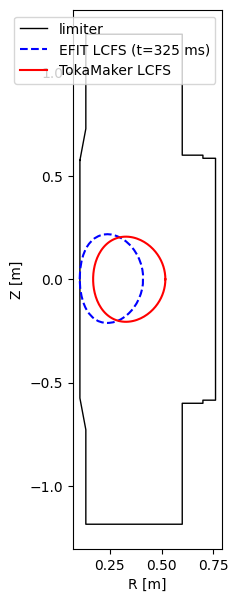

scalar             EFIT  TokaMaker
ip [kA]          51.048     51.043
axis R [m]        0.275      0.361
beta_pol            nan      5.760
q_95              4.799      2.374


In [ ]:
if OFT_AVAILABLE and result.ok:
    eq_times = np.asarray(ods["equilibrium.time"], dtype=float)
    idx = int(np.argmin(np.abs(eq_times - TIME)))
    efit = ods[f"equilibrium.time_slice.{idx}"]
    tok = result.ods["equilibrium.time_slice.0"]

    fig, ax = plt.subplots(figsize=(5, 7))
    lim = np.asarray(inputs.geometry["limiter"])
    ax.plot(np.r_[lim[:, 0], lim[0, 0]], np.r_[lim[:, 1], lim[0, 1]], "k-", lw=1, label="limiter")
    ax.plot(efit["boundary.outline.r"], efit["boundary.outline.z"],
            "b--", label=f"EFIT LCFS (t={eq_times[idx]*1e3:.0f} ms)")
    ax.plot(tok["boundary.outline.r"], tok["boundary.outline.z"], "r-", label="TokaMaker LCFS")
    ax.set_xlabel("R [m]"); ax.set_ylabel("Z [m]"); ax.set_aspect("equal"); ax.legend()
    plt.show()

    def scalar(node, path):
        # `in` first: reading a missing ODS path creates it, and the packaged
        # sample's EFIT slices do not all carry every global quantity.
        return float(node[path]) if path in node else float("nan")

    rows = [
        ("ip [kA]", scalar(efit, "global_quantities.ip") / 1e3, float(tok["global_quantities.ip"]) / 1e3),
        ("axis R [m]", scalar(efit, "global_quantities.magnetic_axis.r"),
         float(tok["global_quantities.magnetic_axis.r"])),
        ("beta_pol", scalar(efit, "global_quantities.beta_pol"), result.scalars["beta_pol"]),
        ("q_95", scalar(efit, "global_quantities.q_95"), result.scalars["q_95"]),
    ]
    print(f"{'scalar':12s} {'EFIT':>10s} {'TokaMaker':>10s}")
    for name, a, b in rows:
        print(f"{name:12s} {a:10.3f} {b:10.3f}")
else:
    print("no converged equilibrium to compare")

## 8. Plasma-current scan

`scan_tokamaker` varies one `TokaMakerConfig` field (default `ip` [A]) across a
list of values in per-value sub-directories. Pinning `mesh_file` makes every point
reuse the cached mesh — only the solve repeats.


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  3.444E+00
    # of points  =   12541
    # of edges   =   37456
    # of cells   =   24916
    # of boundary points =     164
    # of boundary edges  =     164
    # of boundary cells  =     164
  Resolution statistics:
    hmin =  6.233E-03
    hrms =  1.904E-02
    hmax =  7.829E-02
  Surface grounded at vertex    1272


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix 


Saving gEQDSK: <repo>/notebooks/_tokamaker_run/scan/ip_40kA/g039915.00325
 Using COCOS=2...

**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  3.444E+00
    # of points  =   12541
    # of edges   =   37456
    # of cells   =   24916
    # of boundary points =     164
    # of boundary edges  =     164
    # of boundary cells  =     164
  Resolution statistics:
    hmin =  6.233E-03
    hrms =  1.904E-02
    hmax =  7.829E-02
  Surface grounded at vertex    1272


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix 


Saving gEQDSK: <repo>/notebooks/_tokamaker_run/scan/ip_51kA/g039915.00325
 Using COCOS=2...

**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  3.444E+00
    # of points  =   12541
    # of edges   =   37456
    # of cells   =   24916
    # of boundary points =     164
    # of boundary edges  =     164
    # of boundary cells  =     164
  Resolution statistics:
    hmin =  6.233E-03
    hrms =  1.904E-02
    hmax =  7.829E-02
  Surface grounded at vertex    1272


**** Creating Lagrange FE space
  Order  =    2
  Minlev =   -1

 Computing flux BC matrix 


Saving gEQDSK: <repo>/notebooks/_tokamaker_run/scan/ip_60kA/g039915.00325
 Using COCOS=2...


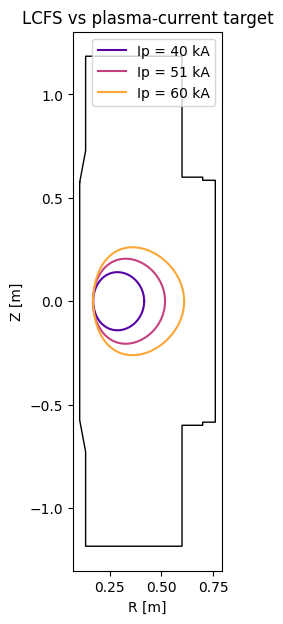

In [ ]:
if OFT_AVAILABLE:
    from dataclasses import replace
    scan_cfg = replace(cfg, workdir=WORKDIR / "scan", mesh_file=inputs.mesh_file)
    scan = tokamaker.scan_tokamaker(ods, scan_cfg, [40.0e3, 51.0e3, 60.0e3], param="ip")

    fig, ax = plt.subplots(figsize=(5, 7))
    lim = np.asarray(inputs.geometry["limiter"])
    ax.plot(np.r_[lim[:, 0], lim[0, 0]], np.r_[lim[:, 1], lim[0, 1]], "k-", lw=1)
    colors = plt.cm.plasma(np.linspace(0.15, 0.8, len(scan)))
    for (value, res), color in zip(scan, colors):
        if res.ok:
            b = res.ods["equilibrium.time_slice.0.boundary.outline"]
            ax.plot(b["r"], b["z"], color=color, label=f"Ip = {value/1e3:.0f} kA")
        else:
            print(f"Ip = {value/1e3:.0f} kA failed: {res.error}")
    ax.set_xlabel("R [m]"); ax.set_ylabel("Z [m]"); ax.set_aspect("equal"); ax.legend()
    ax.set_title("LCFS vs plasma-current target")
    plt.show()
else:
    print("OpenFUSIONToolkit not available — skipping the scan")

## Notes / open tasks

- **Pressure normalization.** Without a `pax` (or `ip_ratio`) target the pressure
  amplitude follows TokaMaker's default profile normalization; for quantitative
  beta comparisons supply one of them (e.g. from Thomson data).
- **Inverse mode.** TokaMaker's isoflux/saddle shape targets with least-squares
  coil currents (scenario design) are not wrapped yet — the forward adapter leaves
  the seams (`set_isoflux`/`set_coil_reg`) for a follow-up.
- **Vessel / eddy currents.** A static solve assigns no current to passive
  conductors, so the vacuum vessel is not meshed. Time-dependent work should mesh
  a continuous vessel annulus (see `TokaMakerConfig.include_vessel`) instead of
  the 950 `pf_passive` filaments.
- **Solver tuning.** `maxits=100` converges across ±20% Ip on the sample shot;
  `urf`/`nl_tol` are exposed for harder cases.